Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [5]:
import gc
import time
from contextlib import contextmanager
import re

In [6]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [7]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [8]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score,fbeta_score, make_scorer

from sklearn.ensemble import RandomForestClassifier

In [9]:
import xgboost as xgb
import shap

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

## data

In [11]:
csv_path_output = '../data/output/'
file_name = 'homecredit_agg.csv'

df = pd.read_csv(f'{csv_path_output + file_name}', encoding='ISO-8859-1')

In [12]:
df.shape

(356251, 798)

In [13]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Explo

## Valeurs manquantes

In [14]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [15]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [16]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Séparation du jeu de données en jeu de  training/validation et jeu de test
train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
print(train_df.shape, test_df.shape)
train_df["TARGET"].value_counts()/train_df.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(train_df.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imput0.2536ation :" , round(test_df.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.2536
Your selected dataframe has 798 columns.
There are 617 columns that have missing values.
(307507, 798) (48744, 798)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.2589
Taux de valeurs manquantes dans jeu de test avant imput0.2536ation : 0.22


# Typage

In [17]:
df.head()

,index,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.dtypes

index                                 int64
SK_ID_CURR                            int64
TARGET                              float64
CODE_GENDER                           int64
FLAG_OWN_CAR                          int64
                                     ...   
CC_NAME_CONTRACT_STATUS_nan_MAX     float64
CC_NAME_CONTRACT_STATUS_nan_MEAN    float64
CC_NAME_CONTRACT_STATUS_nan_SUM     float64
CC_NAME_CONTRACT_STATUS_nan_VAR     float64
CC_COUNT                            float64
Length: 798, dtype: object

In [19]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
df2 = df.copy()
df2 = df2.convert_dtypes()

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df2_memory_usage_gb = df2.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df2_memory_usage_gb} Gb')
del df2
gc.collect()

Dtypes initiaux :
float64    622
int64      176
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.1181129962205887 Gb

Dtypes après conversion :
float64    622
int64      176
dtype: int64

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.382877105847001 Gb


0

In [20]:
# Vérification des dtypes actuels
print("Dtypes initiaux :")
print(df.dtypes.value_counts())
print("\nInfos avant conversion :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

# Analyse de la distribution des données
for column in df.columns:
    if df[column].dtype == 'int64':
        min_val, max_val = df[column].min(), df[column].max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            df[column] = df[column].astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            df[column] = df[column].astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            df[column] = df[column].astype(np.int32)
    elif df[column].dtype == 'float64':
        df[column] = df[column].astype(np.float32)

# Vérification des dtypes après conversion
print("\nDtypes après conversion :")
print(df.dtypes.value_counts())
print("\nInfos sur le DataFrame :")
print(df.info())
df_memory_usage_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f'{df_memory_usage_gb} Gb')

Dtypes initiaux :
float64    622
int64      176
dtype: int64

Infos avant conversion :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float64(622), int64(176)
memory usage: 2.1 GB
None
2.1181129962205887 Gb

Dtypes après conversion :
float32    622
int8       172
int32        2
int16        2
dtype: int64

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Columns: 798 entries, index to CC_COUNT
dtypes: float32(622), int16(2), int32(2), int8(172)
memory usage: 907.8 MB
None
0.8865285664796829 Gb


In [21]:
df['TARGET'].value_counts(dropna=False)

0.0    282682
NaN     48744
1.0     24825
Name: TARGET, dtype: int64

In [22]:
def check_target(df):
    # Calculer la distribution de la cible
    target_counts = df['TARGET'].value_counts()
    target_percentages = df['TARGET'].value_counts(normalize=True) * 100

    fig, ax = plt.subplots(figsize=(7, 6))
    plt.title("Distribution de la cible", fontsize=15)
    sns.countplot(x='TARGET', data=df)

    # Ajouter les étiquettes de comptage sur les barres
    for container in ax.containers:
        ax.bar_label(container, size=12, fmt='%.0f')

    plt.show()

    # Imprimer les pourcentages de chaque sous-élément
    for target, count, percentage in zip(target_counts.index, target_counts, target_percentages):
        print(f"TARGET {target}: {count} occurrences ({percentage:.2f}%)")

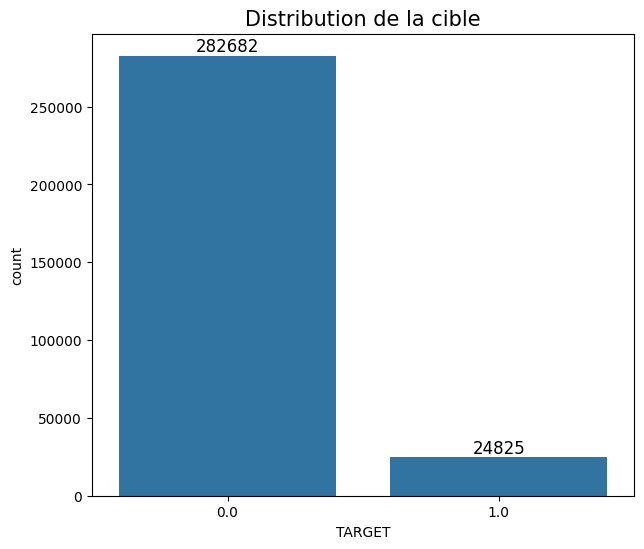

TARGET 0.0: 282682 occurrences (91.93%)
TARGET 1.0: 24825 occurrences (8.07%)


In [23]:
check_target(df)

In [24]:
# Séparer les données en X_train et X_test
X_train = df[df['TARGET'].notna()]
X_test = df[df['TARGET'].isna()]

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)

Dimensions de X_train : (307507, 798)
Dimensions de X_test : (48744, 798)


In [25]:
X_train['TARGET'].value_counts(dropna=False)

0.0    282682
1.0     24825
Name: TARGET, dtype: int64

In [26]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
63543549


In [27]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                               Feature  Missing Percentage
0                        REFUSED_AMT_DOWN_PAYMENT_MEAN           85.311554
1                       REFUSED_RATE_DOWN_PAYMENT_MEAN           85.311554
2                        REFUSED_RATE_DOWN_PAYMENT_MAX           85.311554
3                        REFUSED_RATE_DOWN_PAYMENT_MIN           85.311554
4                         REFUSED_AMT_DOWN_PAYMENT_MIN           85.311554
5                         REFUSED_AMT_DOWN_PAYMENT_MAX           85.311554
6                          REFUSED_APP_CREDIT_PERC_VAR           84.014348
7                           CC_AMT_PAYMENT_CURRENT_VAR           80.286953
8                    CC_CNT_DRAWINGS_OTHER_CURRENT_VAR           80.262888
9                      CC_AMT_DRAWINGS_ATM_CURRENT_VAR           80.262888
10                     CC_AMT_DRAWINGS_POS_CURRENT_VAR           80.262888
11                   CC_AMT_DRAWINGS_OTHER_CURRENT_V

In [28]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [29]:
missing_values_count(df)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                       184            23.057644
0-20%                    325            40.726817
20-40%                    44             5.513784
40-60%                    33             4.135338
60-100%                  212            26.566416


# Modélisations + feature importance

In [38]:
# Séparer les données en X_train et X_test
train_df = df[df['TARGET'].notnull()]
test_df = df[df['TARGET'].isnull()]

print("Dimensions de train :", train_df.shape)
print("Dimensions de test :", test_df.shape)

Dimensions de train : (307507, 798)
Dimensions de test : (48744, 798)


In [39]:
# Séparer les caractéristiques et la cible
X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [40]:
X = X.drop(columns=['index', 'SK_ID_CURR'])
X.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,0,0,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Choix des modèles :

XGBoost, LightGBM & RandomForest peuvent gérer l'entrainement avec des données manquantes, permettant de mettre en place le type de nettoyage suivant avant le futur "vrai" entraînement :

- recherche de features principales communes
- garder uniquement les features principales
- opérer au nettoyage (réduction NA + SMOTE) sur dataframe réduit
- entraîner sur dataframe réduit

## XGBoost

### Model

In [42]:
# Convertir les données en DMatrix pour XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Définir les paramètres du modèle XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle XGBoost
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

In [43]:
# Prédire les probabilités pour la classe positive
y_pred_proba = xgb_model.predict(dtest)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_roc

0.7718090911922908

### Feature Importance (SHAP)

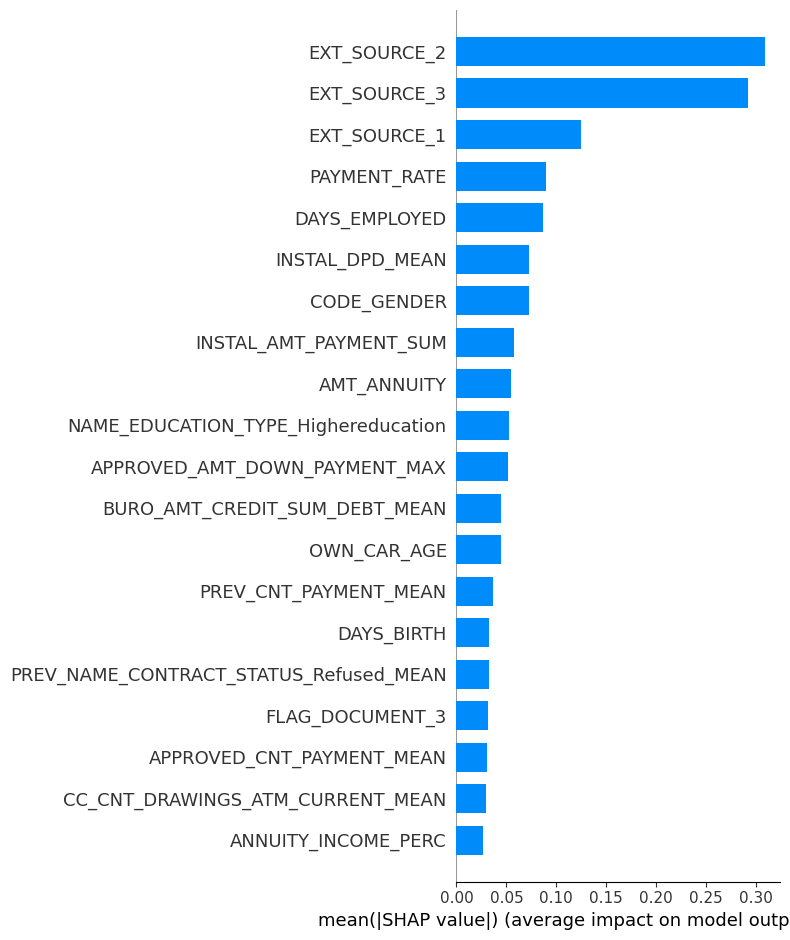

In [44]:
# Calculer les valeurs SHAP
model1_explainer = shap.TreeExplainer(xgb_model)
model1_shap_values = model1_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model1_shap_values, X_test, plot_type='bar')

## LightGBM

### Model

In [45]:
# Convertir les données en Dataset pour LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)

# Définir les paramètres du modèle LightGBM
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Entraîner le modèle LightGBM
LGBM_model = lgb.train(params, dtrain, num_boost_round=100)

[LightGBM] [Info] Number of positive: 17383, number of negative: 197871
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.469894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99496
[LightGBM] [Info] Number of data points in the train set: 215254, number of used features: 784
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080756 -> initscore=-2.432123
[LightGBM] [Info] Start training from score -2.432123
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [46]:
# Prédire les probabilités pour la classe positive
y_pred_proba = LGBM_model.predict(X_test)

# Calculer l'AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc_roc}")

AUC-ROC: 0.771678622613297


### Feature Importance (SHAP)

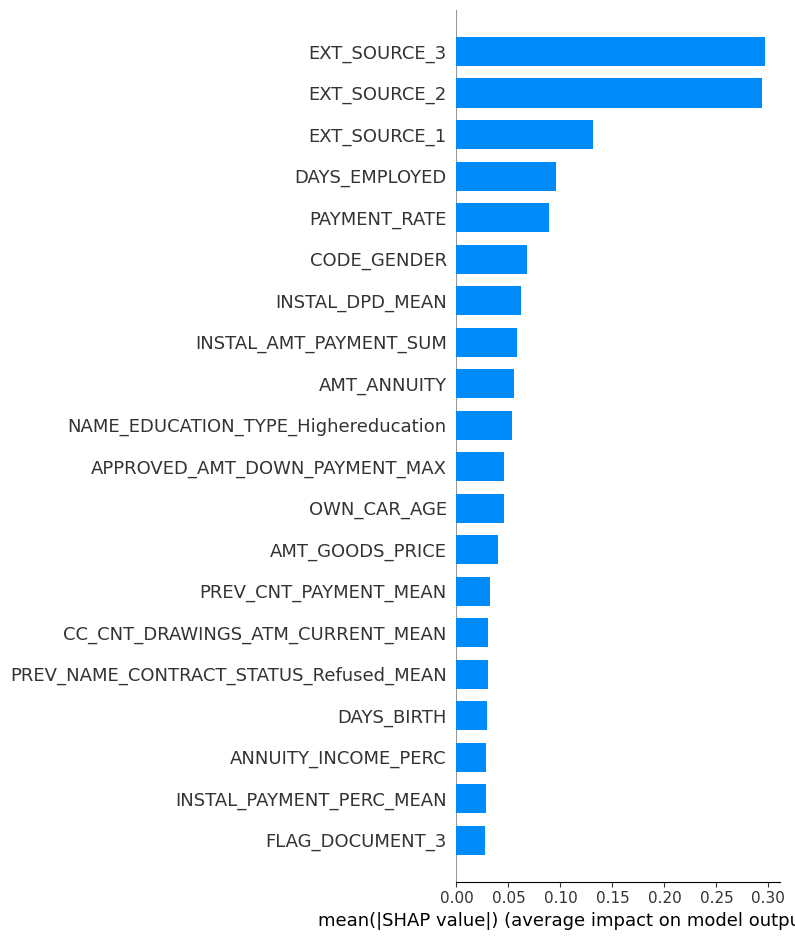

In [47]:
# Calculer les valeurs SHAP
model2_explainer = shap.TreeExplainer(LGBM_model)
model2_shap_values = model2_explainer.shap_values(X_test)

# Visualiser les valeurs SHAP
shap.summary_plot(model2_shap_values, X_test, plot_type='bar')

## Random Forest

### Model

In [48]:
# Initialiser le modèle Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Prédire les probabilités pour la classe positive
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculer le score ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc}")

ROC-AUC Score: 0.7115227885292257


### Feature Importance (most important features)

In [50]:
# Obtenir l'importance des caractéristiques
feature_importances = model.feature_importances_

# Créer un DataFrame pour afficher les importances des caractéristiques
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Afficher l'importance des caractéristiques
print("Importance des caractéristiques :")
print(feature_importance_df)

Importance des caractéristiques :
                                               Feature    Importance
31                                        EXT_SOURCE_2  1.660796e-02
32                                        EXT_SOURCE_3  1.347692e-02
30                                        EXT_SOURCE_1  7.570926e-03
10                                       DAYS_EMPLOYED  6.608330e-03
240                                 DAYS_EMPLOYED_PERC  6.255970e-03
9                                           DAYS_BIRTH  6.080936e-03
243                                ANNUITY_INCOME_PERC  5.319658e-03
11                                   DAYS_REGISTRATION  5.286836e-03
12                                     DAYS_ID_PUBLISH  5.253837e-03
246                               BURO_DAYS_CREDIT_MAX  5.080737e-03
247                              BURO_DAYS_CREDIT_MEAN  4.966662e-03
308                             ACTIVE_DAYS_CREDIT_MAX  4.844885e-03
244                                       PAYMENT_RATE  4.764249e-03


In [51]:
feature_importance_df.shape

(795, 2)

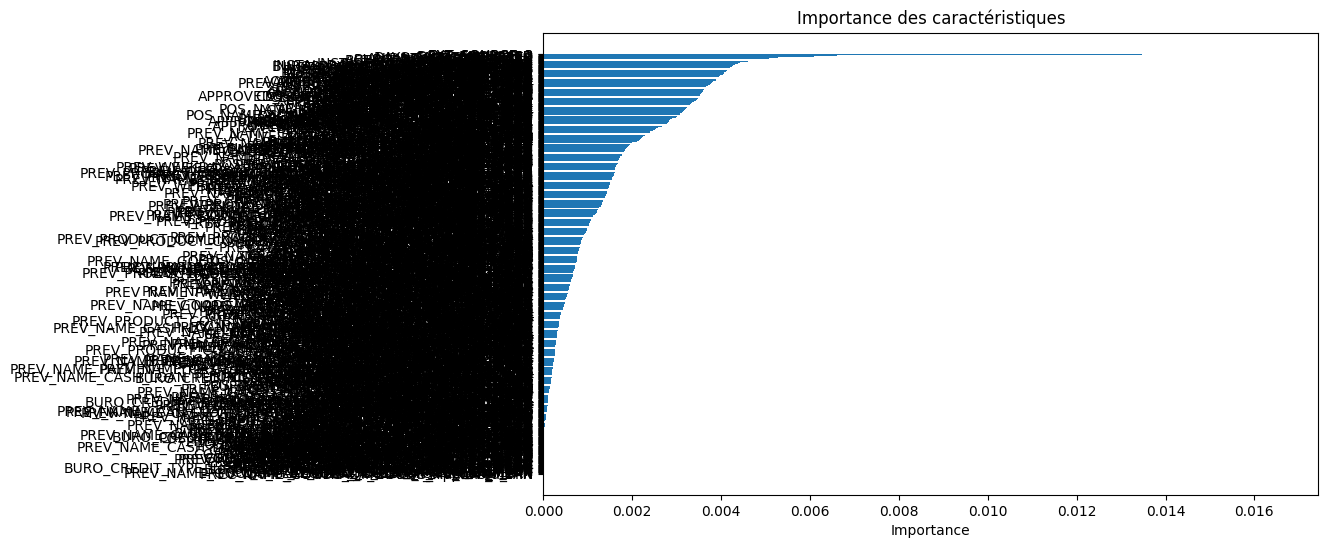

In [52]:
# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Importance des caractéristiques')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

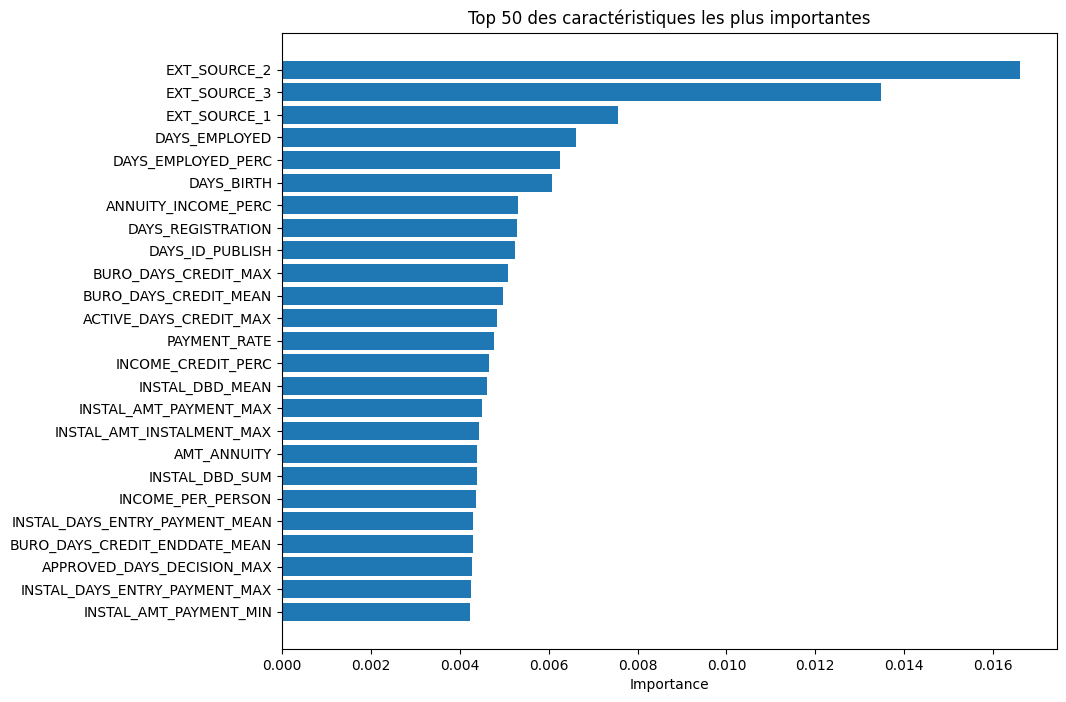

In [53]:
# Sélectionner le top des caractéristiques les plus importantes
top_features = feature_importance_df.head(25)

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 50 des caractéristiques les plus importantes')
plt.gca().invert_yaxis()  # Inverser l'axe y pour afficher la caractéristique la plus importante en haut
plt.show()

## Consolidation / Sélection Features

In [54]:
# Calculer l'importance moyenne absolue des valeurs SHAP pour chaque modèle
shap_importance_model1 = np.mean(np.abs(model1_shap_values), axis=0)
shap_importance_model2 = np.mean(np.abs(model2_shap_values), axis=0)

# Créer des DataFrames pour les importances SHAP
shap_importance_df_model1 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model1_shap_values.shape[1])],
    'Importance': shap_importance_model1
})

shap_importance_df_model2 = pd.DataFrame({
    'Feature': [f'Feature_{i}' for i in range(model2_shap_values.shape[1])],
    'Importance': shap_importance_model2
})

# Normaliser les importances pour chaque modèle
def normalize_importance(df):
    df['Importance'] = (df['Importance'] - df['Importance'].min()) / (df['Importance'].max() - df['Importance'].min())
    return df

shap_importance_df_model1 = normalize_importance(shap_importance_df_model1)
shap_importance_df_model2 = normalize_importance(shap_importance_df_model2)
feature_importance_df = normalize_importance(feature_importance_df)

# Combiner les importances normalisées
combined_importance = pd.DataFrame({
    'Feature': feature_importance_df['Feature'],
    'Combined_Importance': (shap_importance_df_model1['Importance'] +
                             shap_importance_df_model2['Importance'] +
                             feature_importance_df['Importance']) / 3,
    'XGBoost_Importance': shap_importance_df_model1['Importance'],
    'Light_GBM_Importance': shap_importance_df_model2['Importance'],
    'RandomForest_Importance': feature_importance_df['Importance']
})

# Trier les caractéristiques par leur importance combinée
combined_importance = combined_importance.sort_values(by='Combined_Importance', ascending=False)

# Sélectionner les 40 caractéristiques les plus importantes
top_40_features = combined_importance.head(40)

# Afficher les 40 caractéristiques les plus importantes
print("Top 40 des caractéristiques les plus importantes :")
print(top_40_features)

Top 40 des caractéristiques les plus importantes :
                                    Feature  Combined_Importance  \
31                             EXT_SOURCE_2             0.997729   
32                             EXT_SOURCE_3             0.918832   
30                             EXT_SOURCE_1             0.433837   
10                            DAYS_EMPLOYED             0.333569   
244                            PAYMENT_RATE             0.291914   
630                         INSTAL_DPD_MEAN             0.218169   
649                  INSTAL_AMT_PAYMENT_SUM             0.212068   
6                               AMT_ANNUITY             0.208984   
9                                DAYS_BIRTH             0.190829   
0                               CODE_GENDER             0.174338   
243                     ANNUITY_INCOME_PERC             0.166984   
564           APPROVED_AMT_DOWN_PAYMENT_MAX             0.163889   
240                      DAYS_EMPLOYED_PERC             0.155781 

## Réduction DF

In [55]:
top_40_features_target = top_40_features.copy()
top_40_features_target.loc[-1] = 'TARGET'

In [56]:
# Réduire dataframe
df_reduced = df[top_40_features_target['Feature']]
df_reduced.shape

(356251, 41)

In [73]:
def check_missing(df):
    # Calculer le nombre total de valeurs manquantes
    total_missing = df.isna().sum().sum()
    
    # Calculer le pourcentage de valeurs manquantes
    total_cells = df.size
    percentage_missing = (total_missing / total_cells) * 100
    
    # Afficher le total et le pourcentage de valeurs manquantes
    print(f"Total de cellules dans df_reduced: {total_cells}")
    print(f"Total de valeurs manquantes dans df_reduced: {total_missing}")
    print(f"Pourcentage de valeurs manquantes dans df_reduced: {percentage_missing:.2f}%")

In [74]:
check_missing(df_reduced)

Total de cellules dans df_reduced: 13893789
Total de valeurs manquantes dans df_reduced: 1325918
Pourcentage de valeurs manquantes dans df_reduced: 9.54%


In [75]:
missing_values_count(df_reduced)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                         6            15.384615
0-20%                     29            74.358974
20-40%                     2             5.128205
40-60%                     1             2.564103
60-100%                    1             2.564103


In [76]:
missing_values = df_reduced.isna().sum()
missing_percentage = (missing_values / len(df_reduced)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Afficher les valeurs manquantes et les pourcentages
print("Valeurs manquantes et pourcentages dans df_reduced :")
print(missing_info)

Valeurs manquantes et pourcentages dans df_reduced :
                                        Missing Values  Missing Percentage (%)
EXT_SOURCE_2                                       668                0.187508
EXT_SOURCE_3                                     69633               19.546050
EXT_SOURCE_1                                    193908               54.430163
PAYMENT_RATE                                        36                0.010105
INSTAL_DPD_MEAN                                  16668                4.678724
INSTAL_AMT_PAYMENT_SUM                           16668                4.678724
AMT_ANNUITY                                         36                0.010105
DAYS_BIRTH                                           0                0.000000
CODE_GENDER                                          0                0.000000
ANNUITY_INCOME_PERC                                 36                0.010105
APPROVED_AMT_DOWN_PAYMENT_MAX                    40203               11.285021

In [61]:
def heatmap(df):
    # Affichage de la heatmap des corrélations
    plt.figure(figsize=(30,30))
    sns.heatmap(df.corr() , annot=True, linewidths=.2, cmap="YlGnBu")
    plt.title("Heatmap des corrélations - 'application_train'")

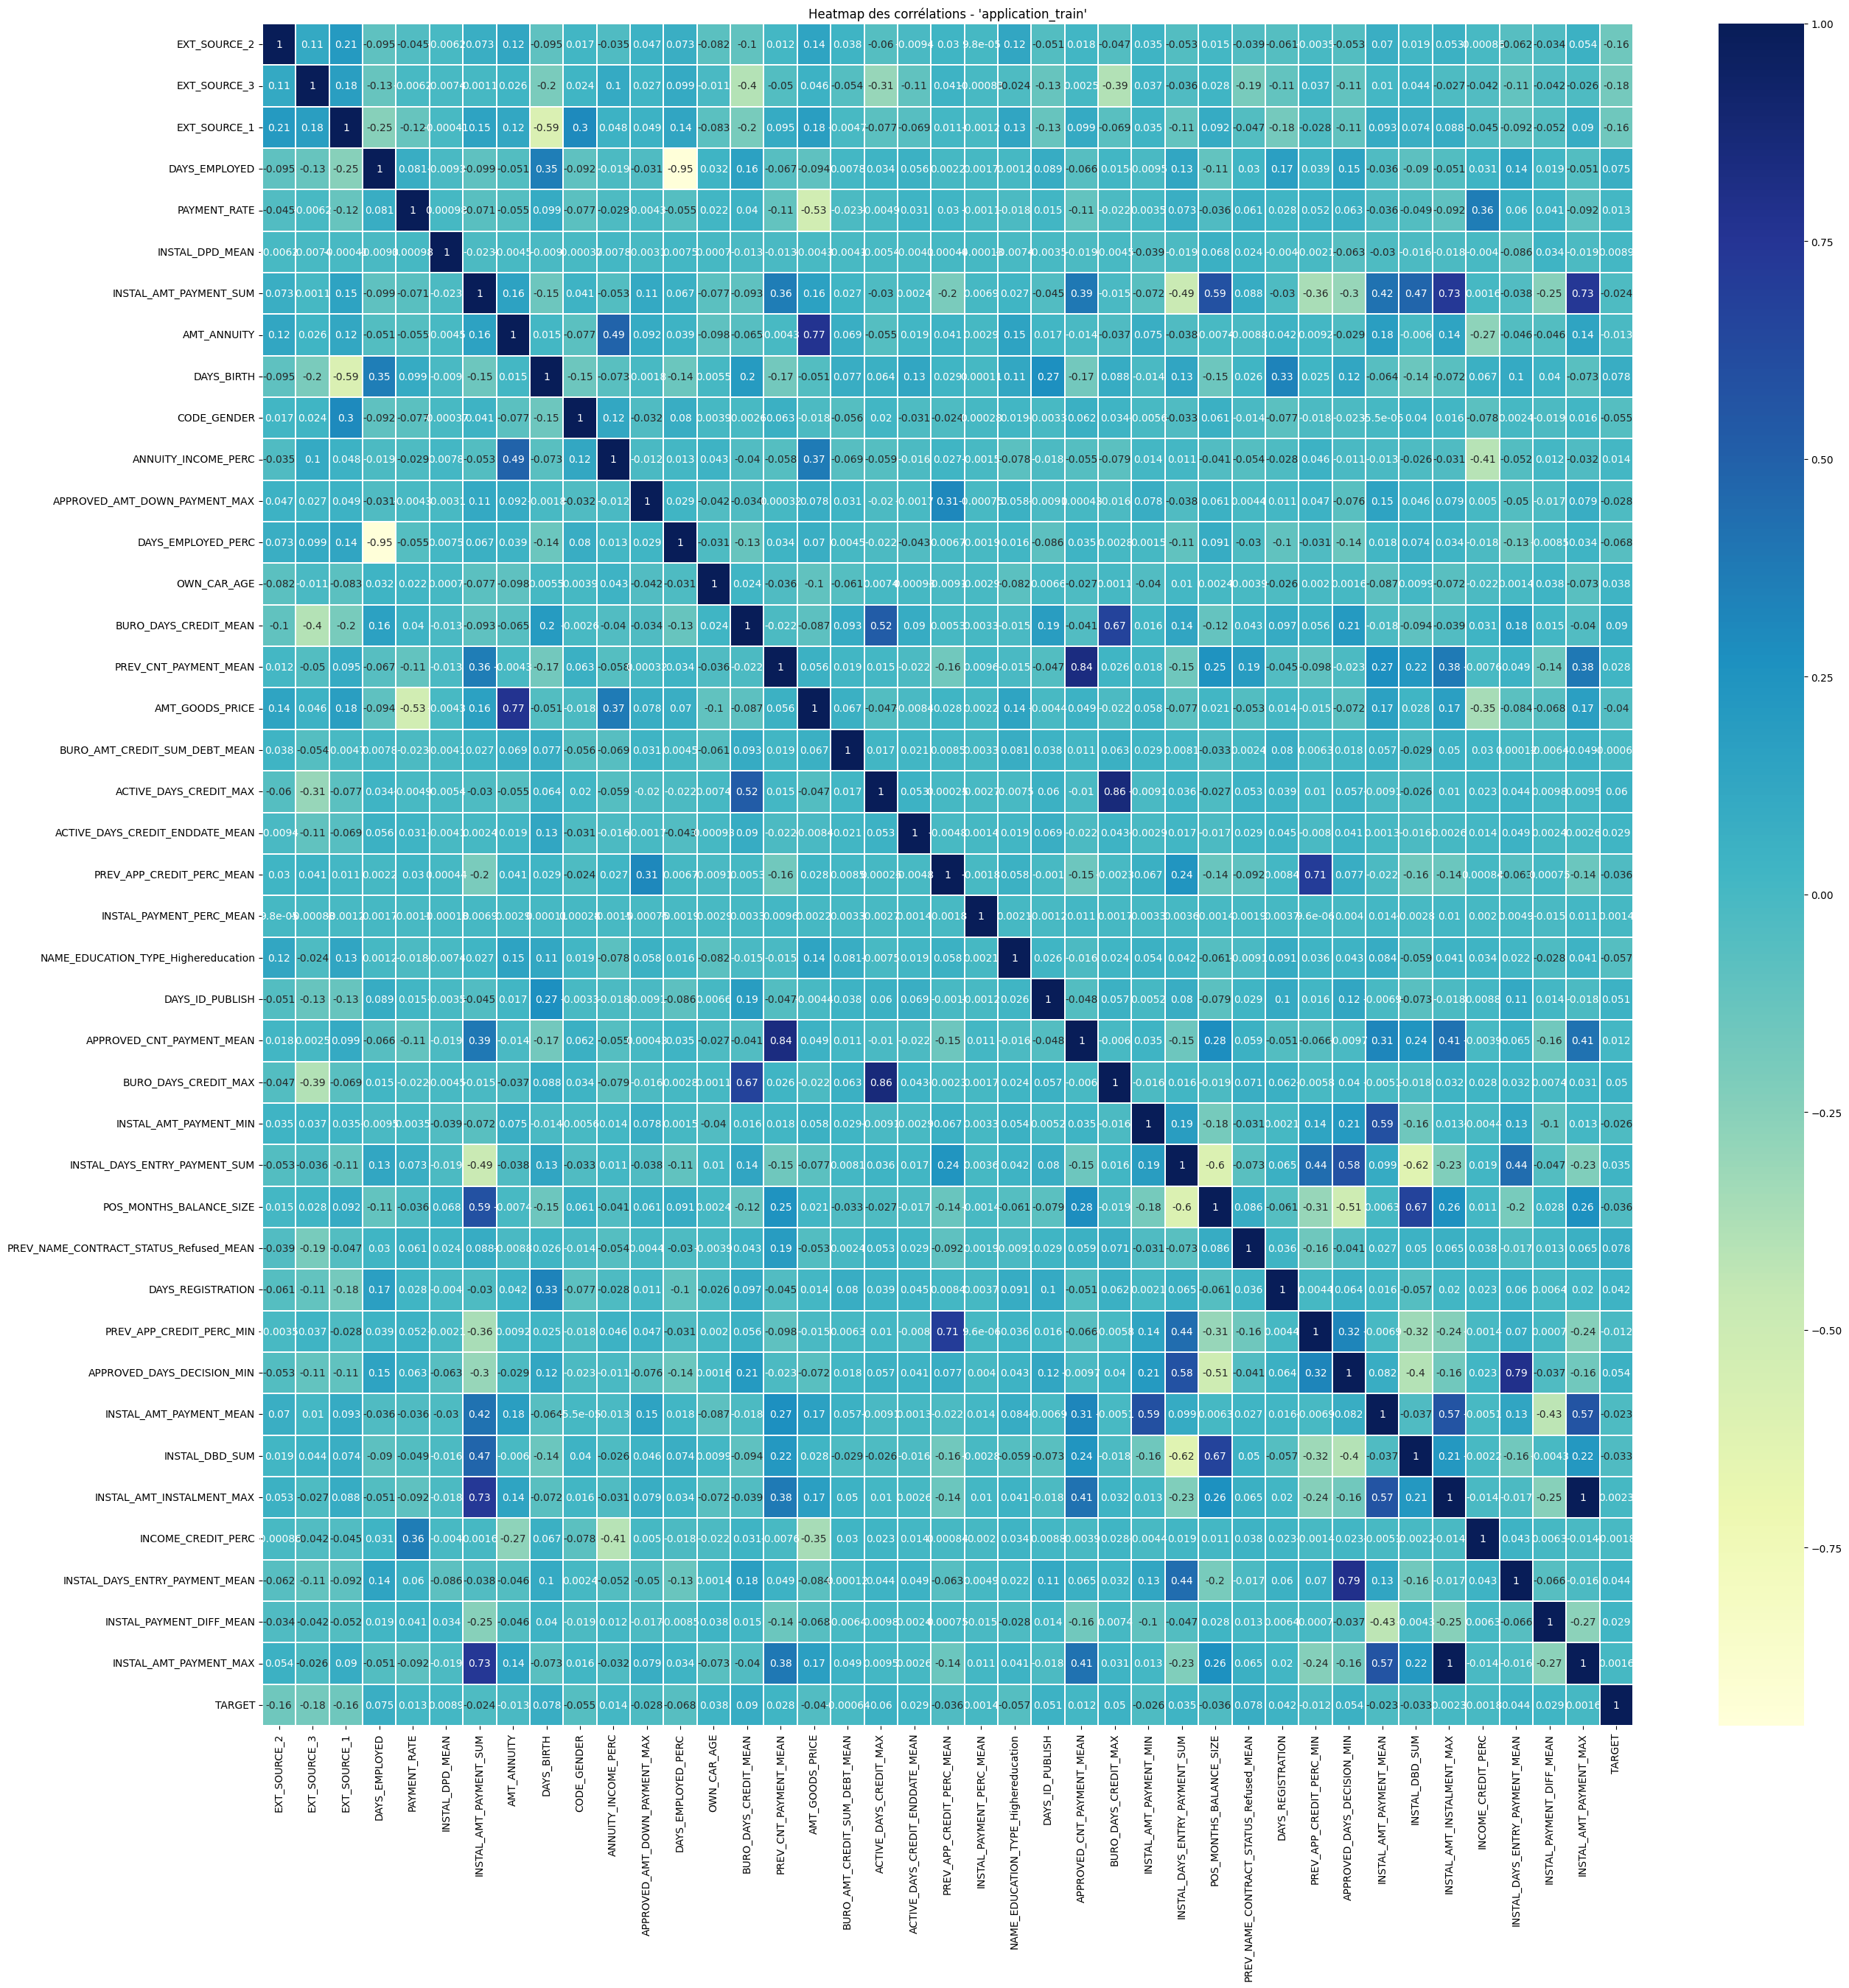

In [66]:
heatmap(df_reduced)

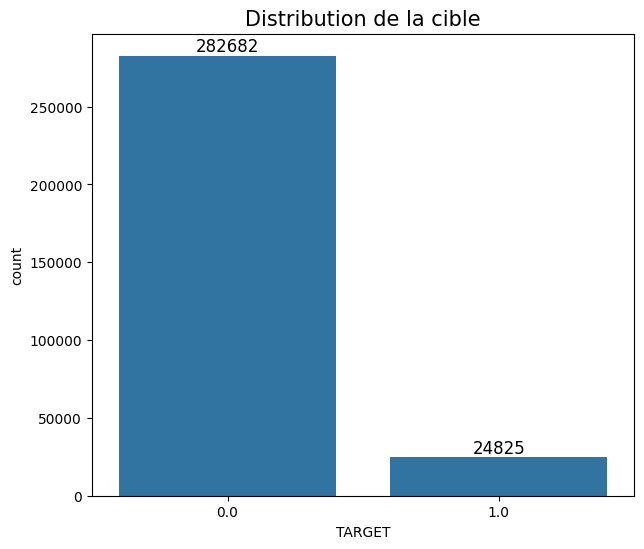

TARGET 0.0: 282682 occurrences (91.93%)
TARGET 1.0: 24825 occurrences (8.07%)


In [67]:
check_target(df_reduced)

### Suppression Corrélations élevées

In [68]:
def remove_highly_correlated_features(df, threshold=0.90):
    # Calculer la matrice de corrélation
    corr_matrix = df.corr().abs()

    # Initialiser un ensemble pour les colonnes à supprimer
    columns_to_drop = set()

    # Parcourir la matrice de corrélation
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > threshold:
                # Calculer la corrélation moyenne pour chaque colonne
                col_i_mean_corr = corr_matrix.iloc[i, :].mean()
                col_j_mean_corr = corr_matrix.iloc[j, :].mean()

                # Conserver la colonne avec la corrélation moyenne la plus faible
                if col_i_mean_corr > col_j_mean_corr:
                    columns_to_drop.add(corr_matrix.columns[i])
                else:
                    columns_to_drop.add(corr_matrix.columns[j])

    # Supprimer les colonnes identifiées
    df_reduced = df.drop(columns=columns_to_drop)

    return df_reduced

In [69]:
df_reduced = remove_highly_correlated_features(df_reduced)

In [70]:
df_reduced.shape

(356251, 39)

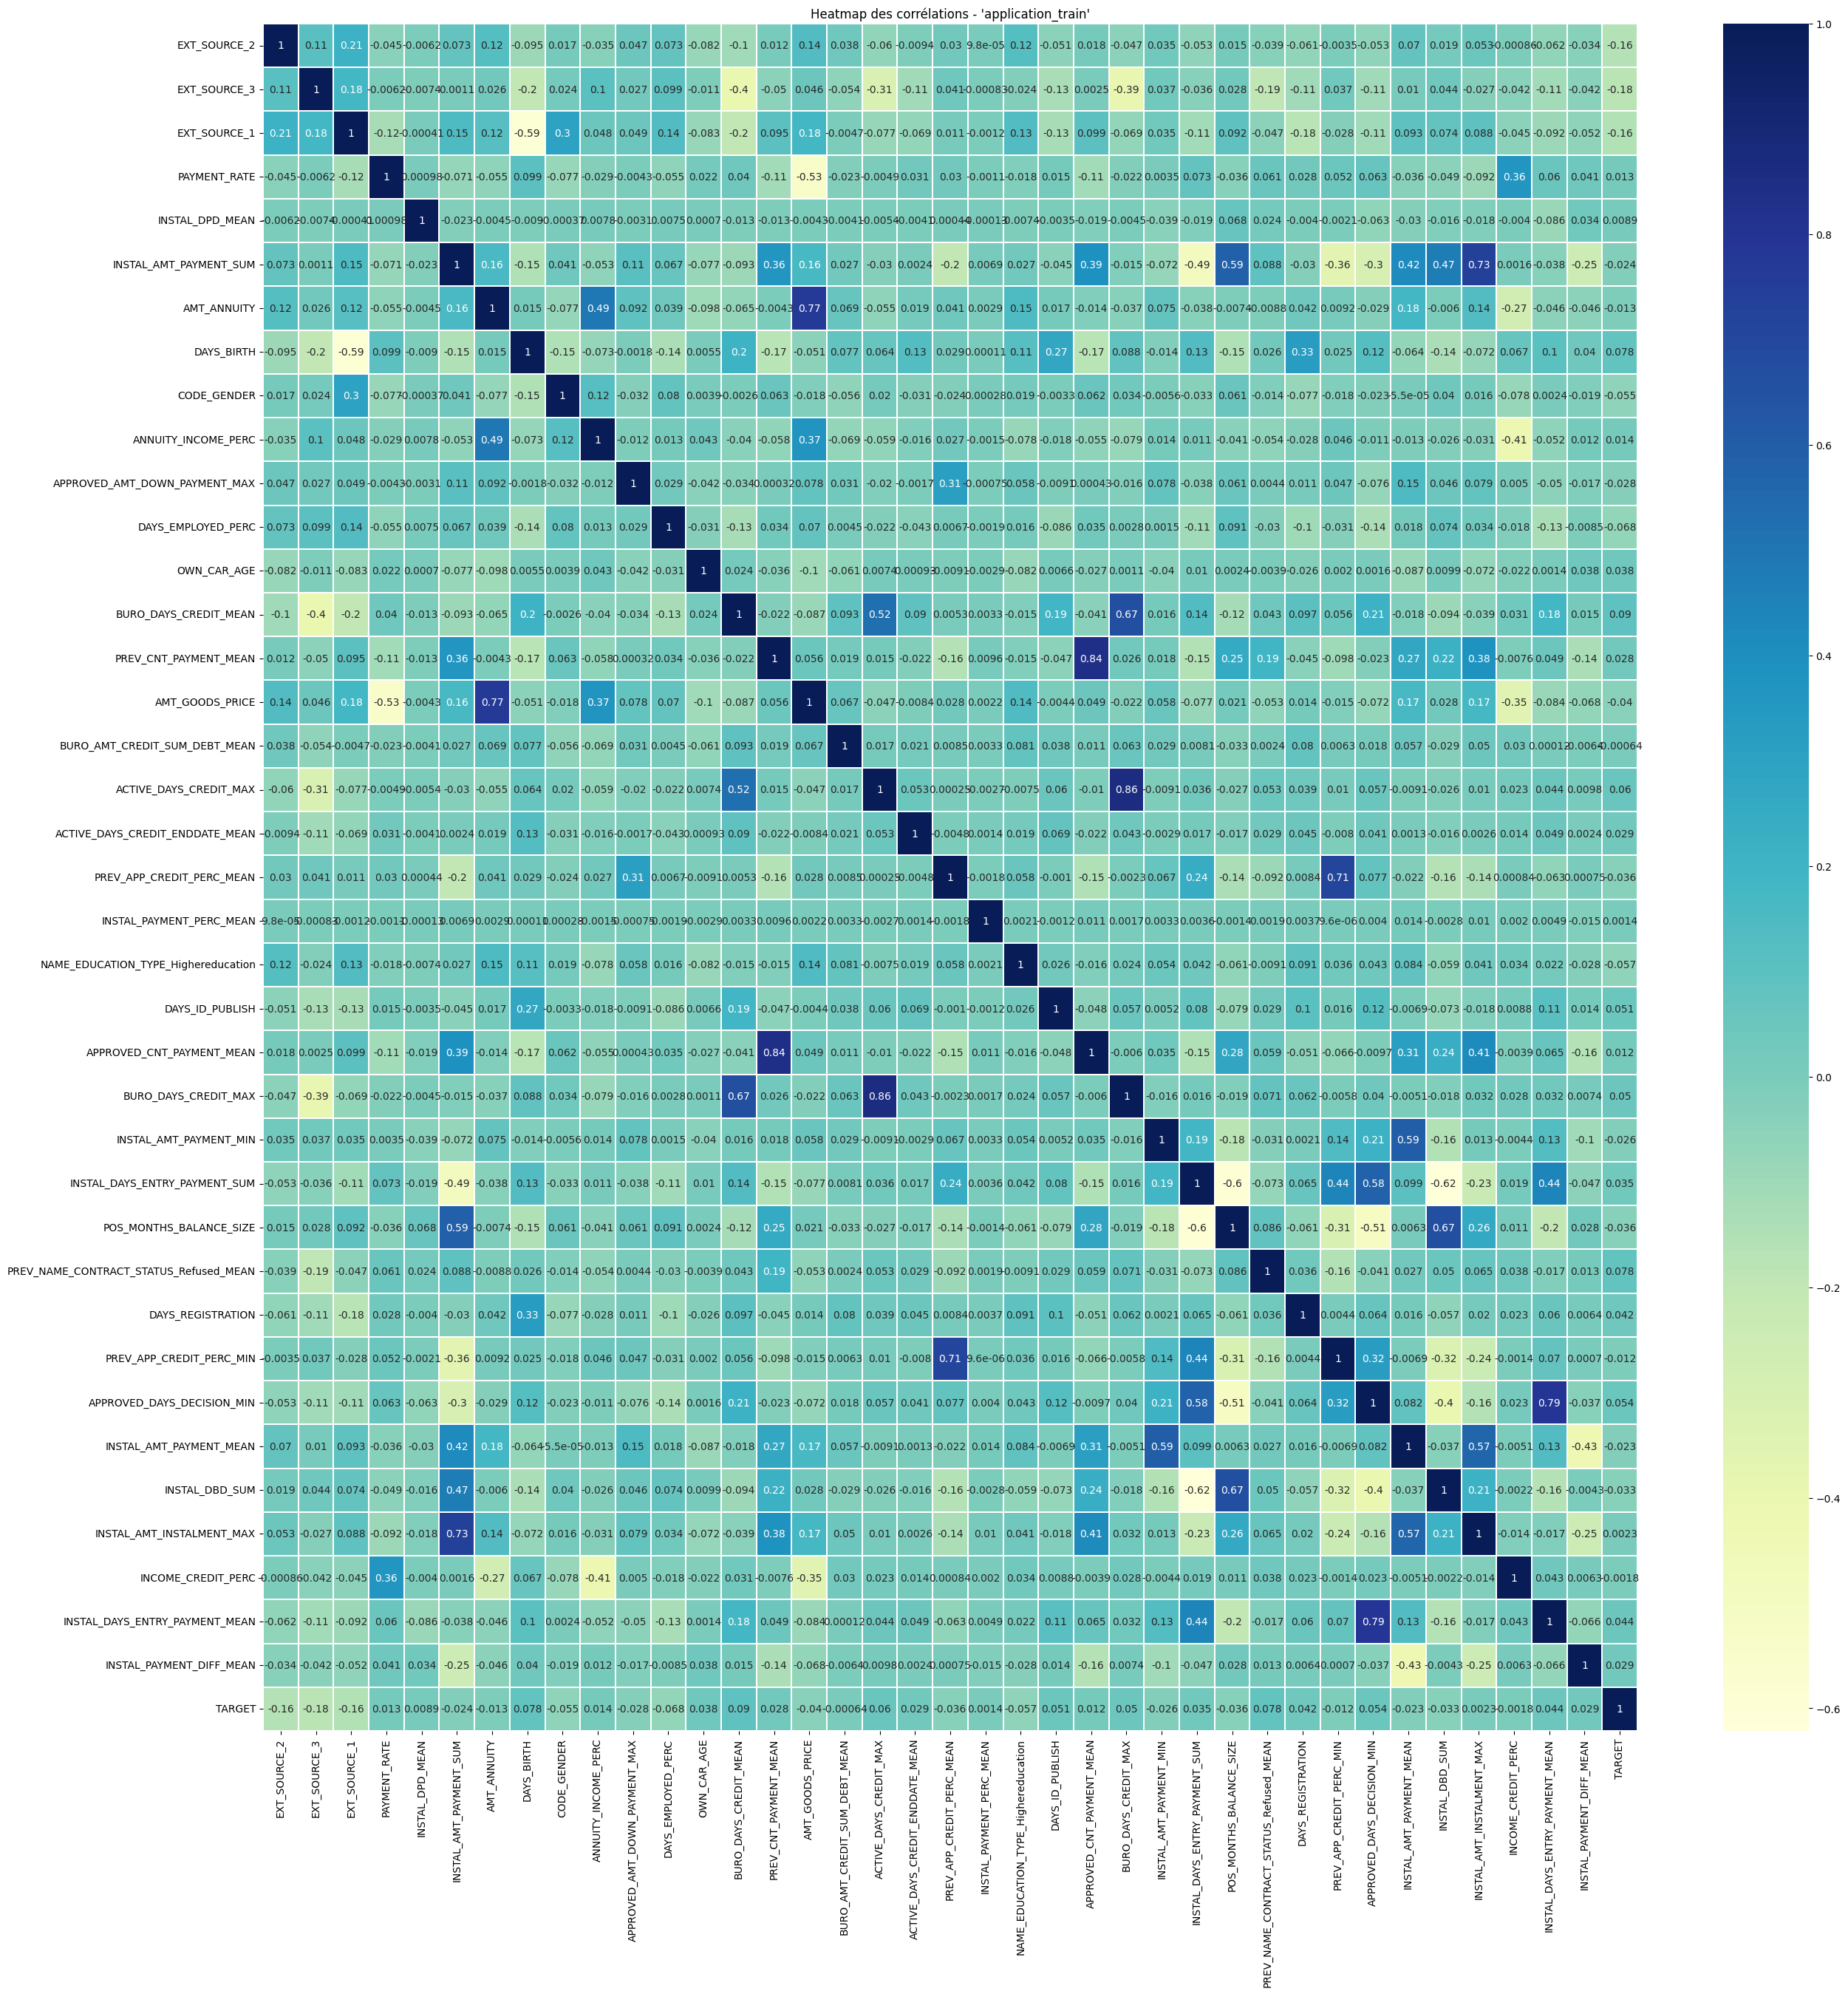

In [71]:
heatmap(df_reduced)

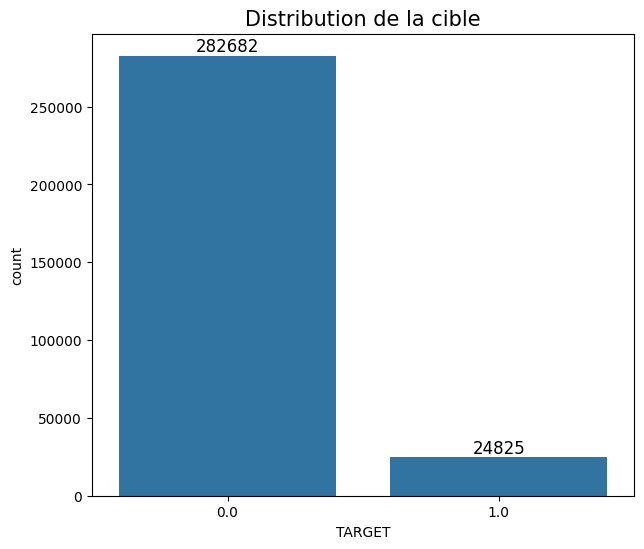

TARGET 0.0: 282682 occurrences (91.93%)
TARGET 1.0: 24825 occurrences (8.07%)


In [72]:
check_target(df_reduced)

In [78]:
df_reduced['TARGET'].value_counts(dropna=False)

0.0    282682
NaN     48744
1.0     24825
Name: TARGET, dtype: int64

### Données manquantes

In [81]:
def check_missing_train_test(df):
    #  Statistiques sur les valeurs manquantes :
    missing_values = missing_values_table(df_reduced)
    df_reduced.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Séparation du jeu de données en jeu de  training/validation et jeu de test
    train_df = df[df['TARGET'].notnull()] # partie du jeu de données qui contient une target
    test_df = df[df['TARGET'].isnull()] # partie du jeu de données qui n'a pas de target
    print(train_df.shape, test_df.shape)
    train_df["TARGET"].value_counts()/train_df.shape[0]
    
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans jeu de train avant traitement :" , round(train_df.isna().mean().mean(),4))
    print("Taux de valeurs manquantes dans jeu de test avant traitement :" , round(test_df.isna().mean().mean(),4))

In [82]:
check_missing_train_test(df_reduced)

Taux de valeurs manquantes dans le df avant imputation : 0.0954
Your selected dataframe has 39 columns.
There are 33 columns that have missing values.
(307507, 39) (48744, 39)
Taux de valeurs manquantes dans jeu de train avant traitement : 0.0948
Taux de valeurs manquantes dans jeu de test avant traitement : 0.0992


In [83]:
# split train test avant traitement
train_df_reduced = df_reduced[df_reduced['TARGET'].notnull()]

test_df_reduced = df_reduced[df_reduced['TARGET'].isnull()]
test_df_reduced = test_df_reduced.drop(columns=['TARGET'])

In [65]:
# Garder uniquement les colonnes avec moins de 50% de données manquantes
# puis garder uniquement les lignes avec 0 donnée manquante.

# Sauvegarder la forme initiale
total_rows_initial, total_cols_initial = df_reduced.shape

# Seuil pour supprimer les colonnes (par exemple, 50% de valeurs manquantes)
threshold = 0.5

# Supprimer les colonnes avec plus de 50% de valeurs manquantes
df_cleaned = df_reduced.dropna(thresh=len(df_reduced) * (1 - threshold), axis=1)

# Supprimer les lignes avec des valeurs manquantes
df_cleaned = df_cleaned.dropna()

# Sauvegarder la forme finale
total_rows_final, total_cols_final = df_cleaned.shape

# Calculer les différences et pourcentages
delta_rows = total_rows_initial - total_rows_final
delta_cols = total_cols_initial - total_cols_final

percentage_rows_removed = (delta_rows / total_rows_initial) * 100
percentage_cols_removed = (delta_cols / total_cols_initial) * 100

print(f"Forme initiale du DataFrame: {total_rows_initial} lignes, {total_cols_initial} colonnes")
print(f"Forme finale du DataFrame: {total_rows_final} lignes, {total_cols_final} colonnes")
print(f"Lignes supprimées: {delta_rows} ({percentage_rows_removed:.2f}%)")
print(f"Colonnes supprimées: {delta_cols} ({percentage_cols_removed:.2f}%)")

Forme initiale du DataFrame: 356251 lignes, 41 colonnes
Forme finale du DataFrame: 143691 lignes, 39 colonnes
Lignes supprimées: 212560 (59.67%)
Colonnes supprimées: 2 (4.88%)


In [91]:
def clean_dataframe(df, threshold=0.5):
    """
    Nettoie un DataFrame en supprimant les colonnes avec plus de 50% de valeurs manquantes
    et les lignes avec des valeurs manquantes.

    Args:
        df (pd.DataFrame): Le DataFrame à nettoyer.
        threshold (float): Seuil pour supprimer les colonnes (par exemple, 0.5 pour 50%).

    Returns:
        pd.DataFrame: Le DataFrame nettoyé.
        dict: Un dictionnaire contenant les statistiques sur les lignes, colonnes et valeurs manquantes supprimées.
    """
    # Sauvegarder la forme initiale et le décompte des valeurs manquantes
    total_rows_initial, total_cols_initial = df.shape
    initial_missing_values = df.isna().sum().sum()

    # Supprimer les colonnes avec plus de 50% de valeurs manquantes
    df_cleaned = df.dropna(thresh=len(df) * (1 - threshold), axis=1)

    # Supprimer les lignes avec des valeurs manquantes
    df_cleaned = df_cleaned.dropna()

    # Sauvegarder la forme finale et le décompte des valeurs manquantes
    total_rows_final, total_cols_final = df_cleaned.shape
    final_missing_values = df_cleaned.isna().sum().sum()

    # Calculer les différences et pourcentages
    delta_rows = total_rows_initial - total_rows_final
    delta_cols = total_cols_initial - total_cols_final
    delta_missing_values = initial_missing_values - final_missing_values

    percentage_rows_removed = (delta_rows / total_rows_initial) * 100
    percentage_cols_removed = (delta_cols / total_cols_initial) * 100
    percentage_missing_values_removed = (delta_missing_values / initial_missing_values) * 100 if initial_missing_values > 0 else 0

    # Créer un dictionnaire pour les statistiques
    stats = {
        "initial_shape": (total_rows_initial, total_cols_initial),
        "final_shape": (total_rows_final, total_cols_final),
        "rows_removed": delta_rows,
        "percentage_rows_removed": percentage_rows_removed,
        "cols_removed": delta_cols,
        "percentage_cols_removed": percentage_cols_removed,
        "initial_missing_values": initial_missing_values,
        "final_missing_values": final_missing_values,
        "missing_values_removed": delta_missing_values,
        "percentage_missing_values_removed": percentage_missing_values_removed
    }

    return df_cleaned, stats

In [92]:
def show_clean_stats(stats):
    print(f"Forme initiale du DataFrame: {stats['initial_shape']}")
    print(f"Forme finale du DataFrame: {stats['final_shape']}")
    print(f"Décomptes null du Dataframe :")
    print(f"Lignes supprimées: {stats['rows_removed']} ({stats['percentage_rows_removed']:.2f}%)")
    print(f"Colonnes supprimées: {stats['cols_removed']} ({stats['percentage_cols_removed']:.2f}%)")
    print(f"Valeurs manquantes initiales: {stats['initial_missing_values']}")
    print(f"Valeurs manquantes finales: {stats['final_missing_values']}")
    print(f"Valeurs manquantes supprimées: {stats['missing_values_removed']} ({stats['percentage_missing_values_removed']:.2f}%)")

In [93]:
# traitement train_df_reduced
train_df_cleaned, train_stats = clean_dataframe(train_df_reduced)
show_clean_stats(train_stats)

Forme initiale du DataFrame: (307507, 39)
Forme finale du DataFrame: (143691, 37)
Décomptes null du Dataframe :
Lignes supprimées: 163816 (53.27%)
Colonnes supprimées: 2 (5.13%)
Valeurs manquantes initiales: 1137326
Valeurs manquantes finales: 0
Valeurs manquantes supprimées: 1137326 (100.00%)


In [94]:
# traitement test_df_reduced
test_df_cleaned, test_stats = clean_dataframe(test_df_reduced)
show_clean_stats(test_stats)

Forme initiale du DataFrame: (48744, 39)
Forme finale du DataFrame: (15588, 37)
Décomptes null du Dataframe :
Lignes supprimées: 33156 (68.02%)
Colonnes supprimées: 2 (5.13%)
Valeurs manquantes initiales: 188592
Valeurs manquantes finales: 0
Valeurs manquantes supprimées: 188592 (100.00%)


In [96]:
#check_missing(test_df_cleaned)

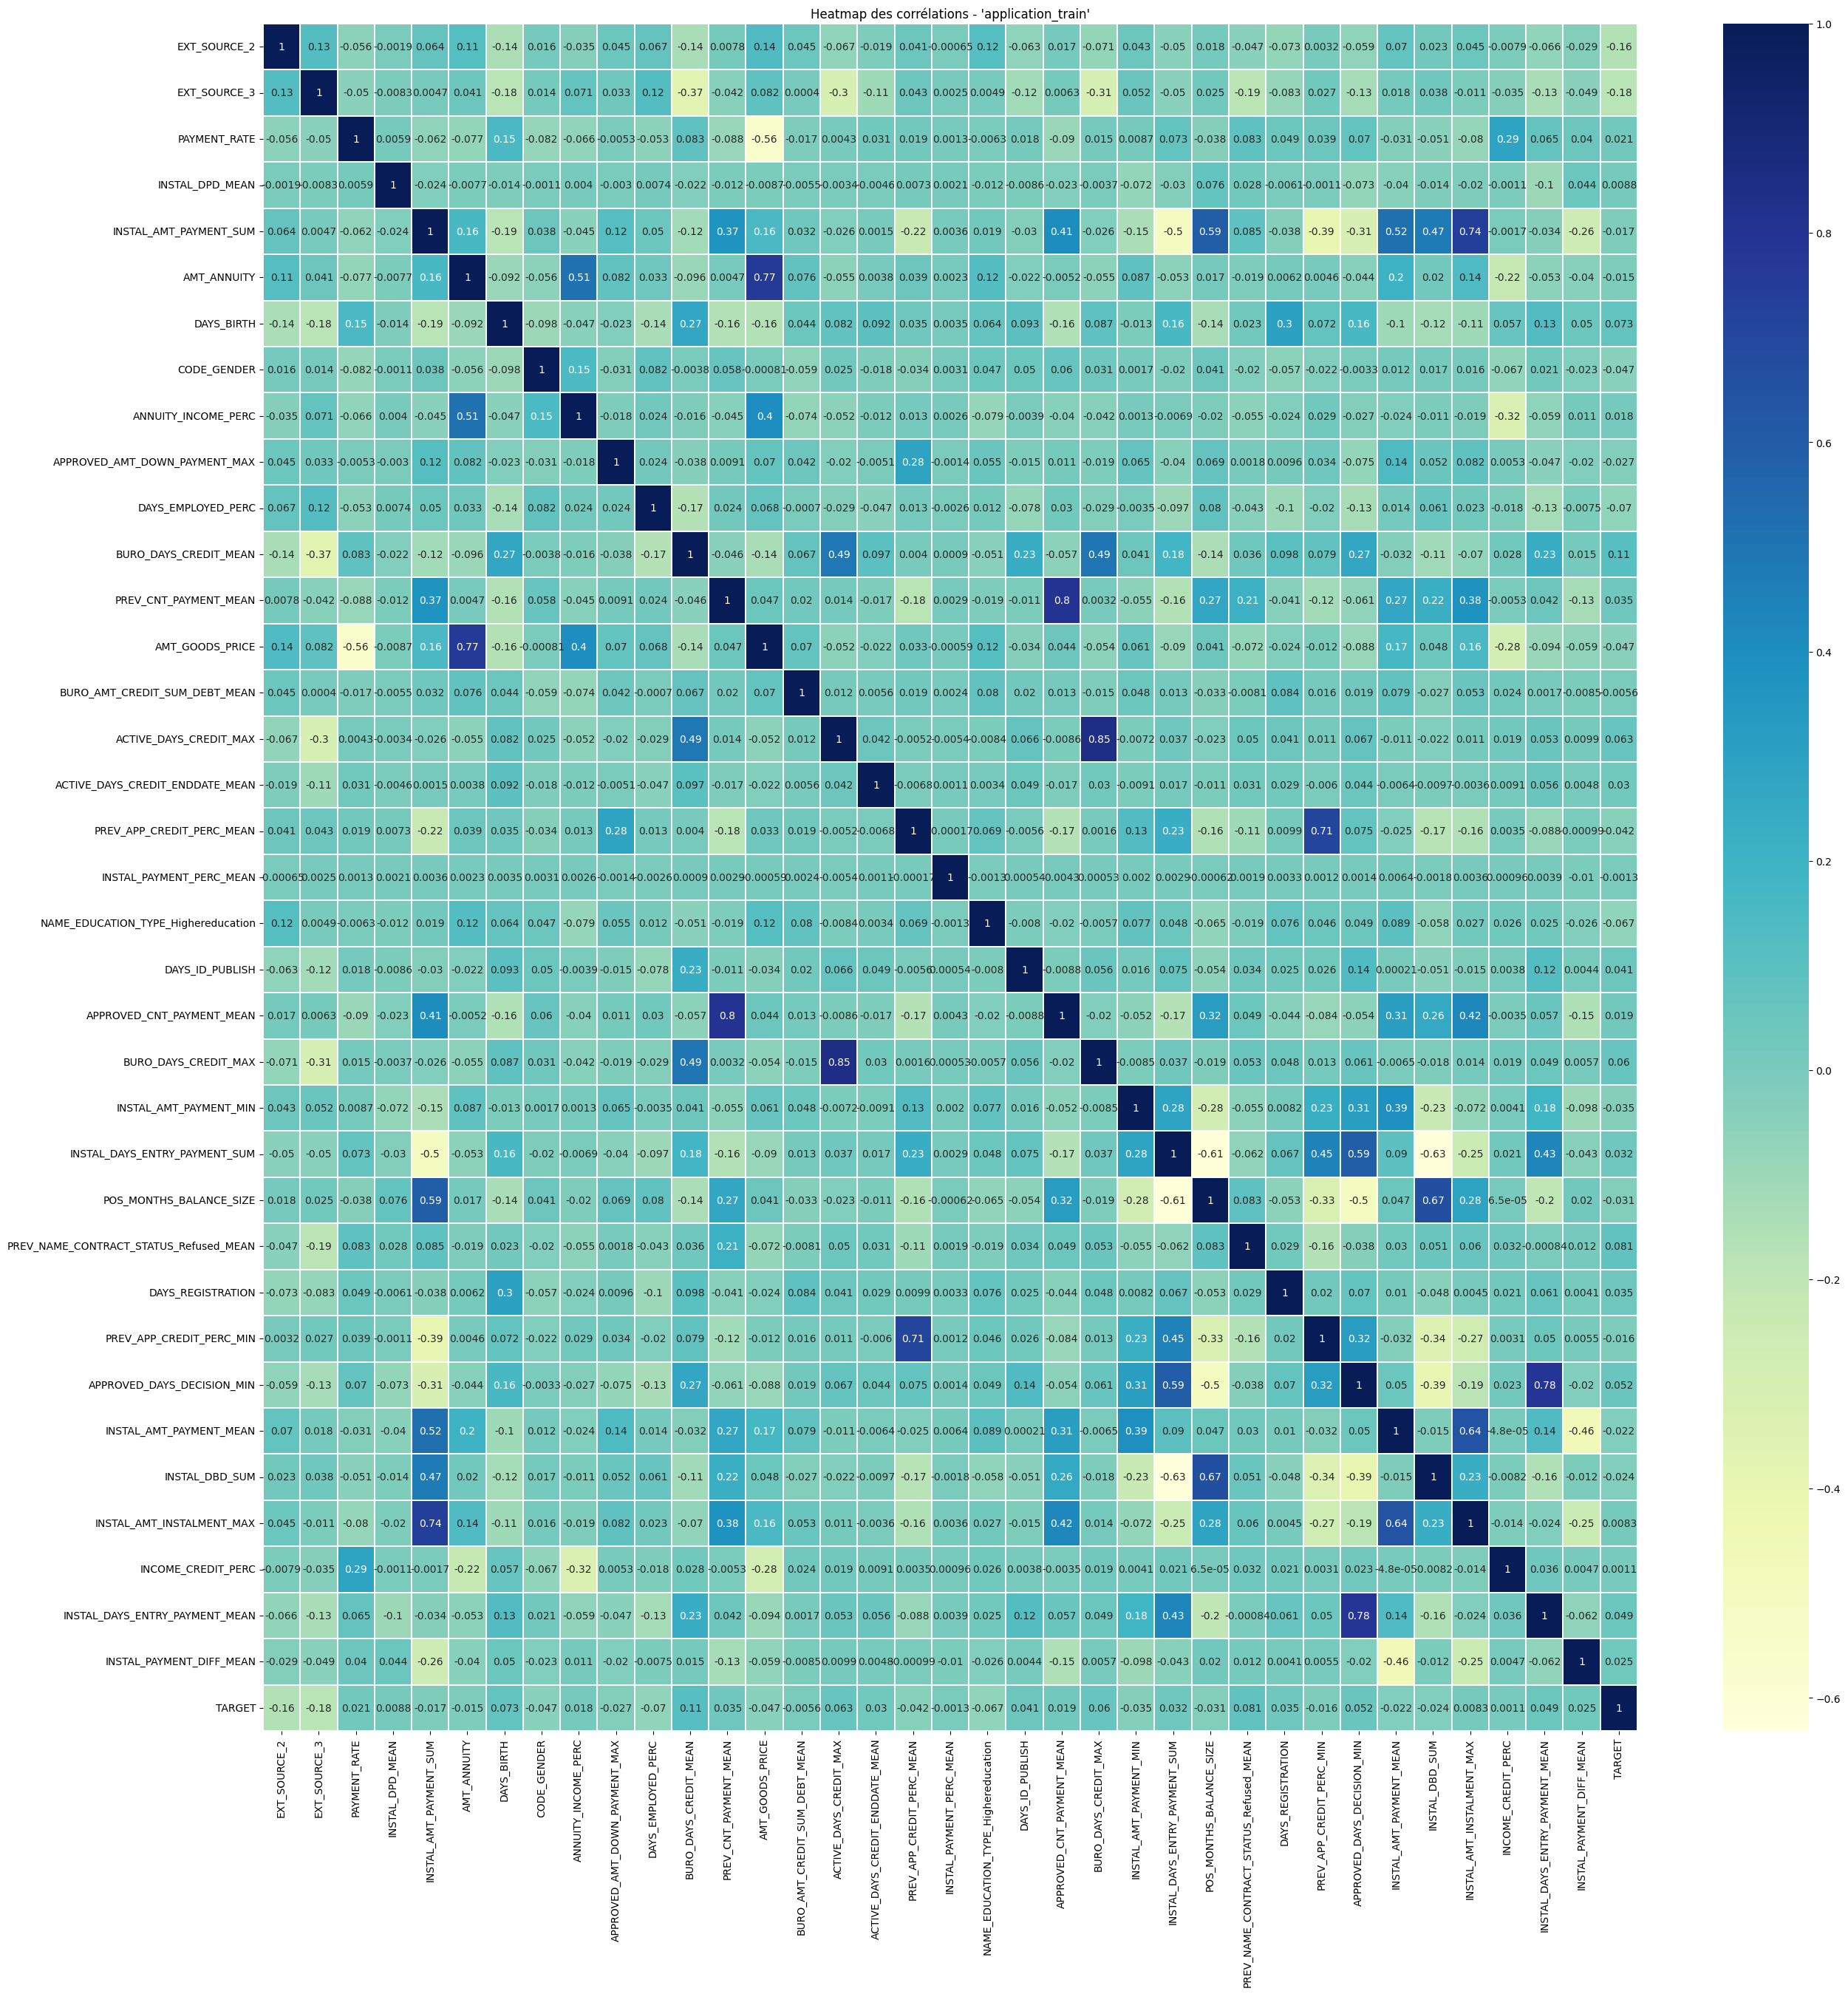

In [97]:
heatmap(train_df_cleaned)

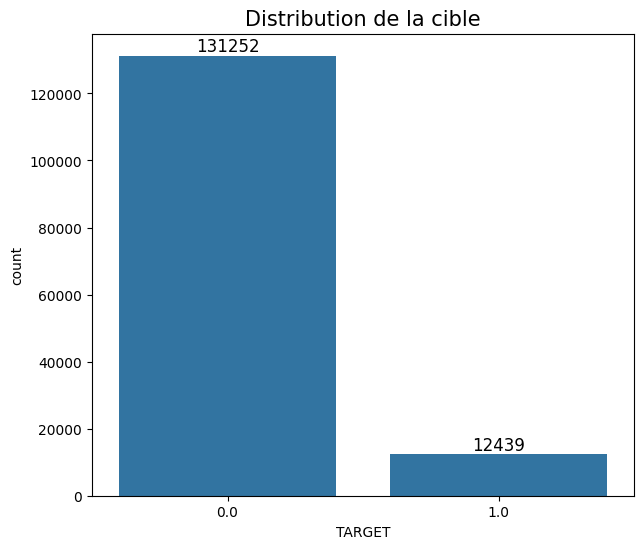

TARGET 0.0: 131252 occurrences (91.34%)
TARGET 1.0: 12439 occurrences (8.66%)


In [98]:
check_target(train_df_cleaned)

### SMOTE

In [99]:
# Séparer les caractéristiques et la cible
X = train_df_cleaned.drop('TARGET', axis=1)
y = train_df_cleaned['TARGET']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Appliquer le SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Afficher la distribution des classes avant et après SMOTE
print("Distribution des classes avant SMOTE :")
print(y_train.value_counts())

print("\nDistribution des classes après SMOTE :")
print(pd.Series(y_res).value_counts())

Distribution des classes avant SMOTE :
0.0    105059
1.0      9893
Name: TARGET, dtype: int64

Distribution des classes après SMOTE :
0.0    105059
1.0    105059
Name: TARGET, dtype: int64


In [101]:
train_df_cleaned_smote = pd.DataFrame(X_res, columns=X.columns)
train_df_cleaned_smote['TARGET'] = y_res

print("\nPremières lignes du DataFrame après SMOTE :")
print(train_df_cleaned_smote.shape)
train_df_cleaned_smote.head()


Premières lignes du DataFrame après SMOTE :
(210118, 37)


,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,0.0


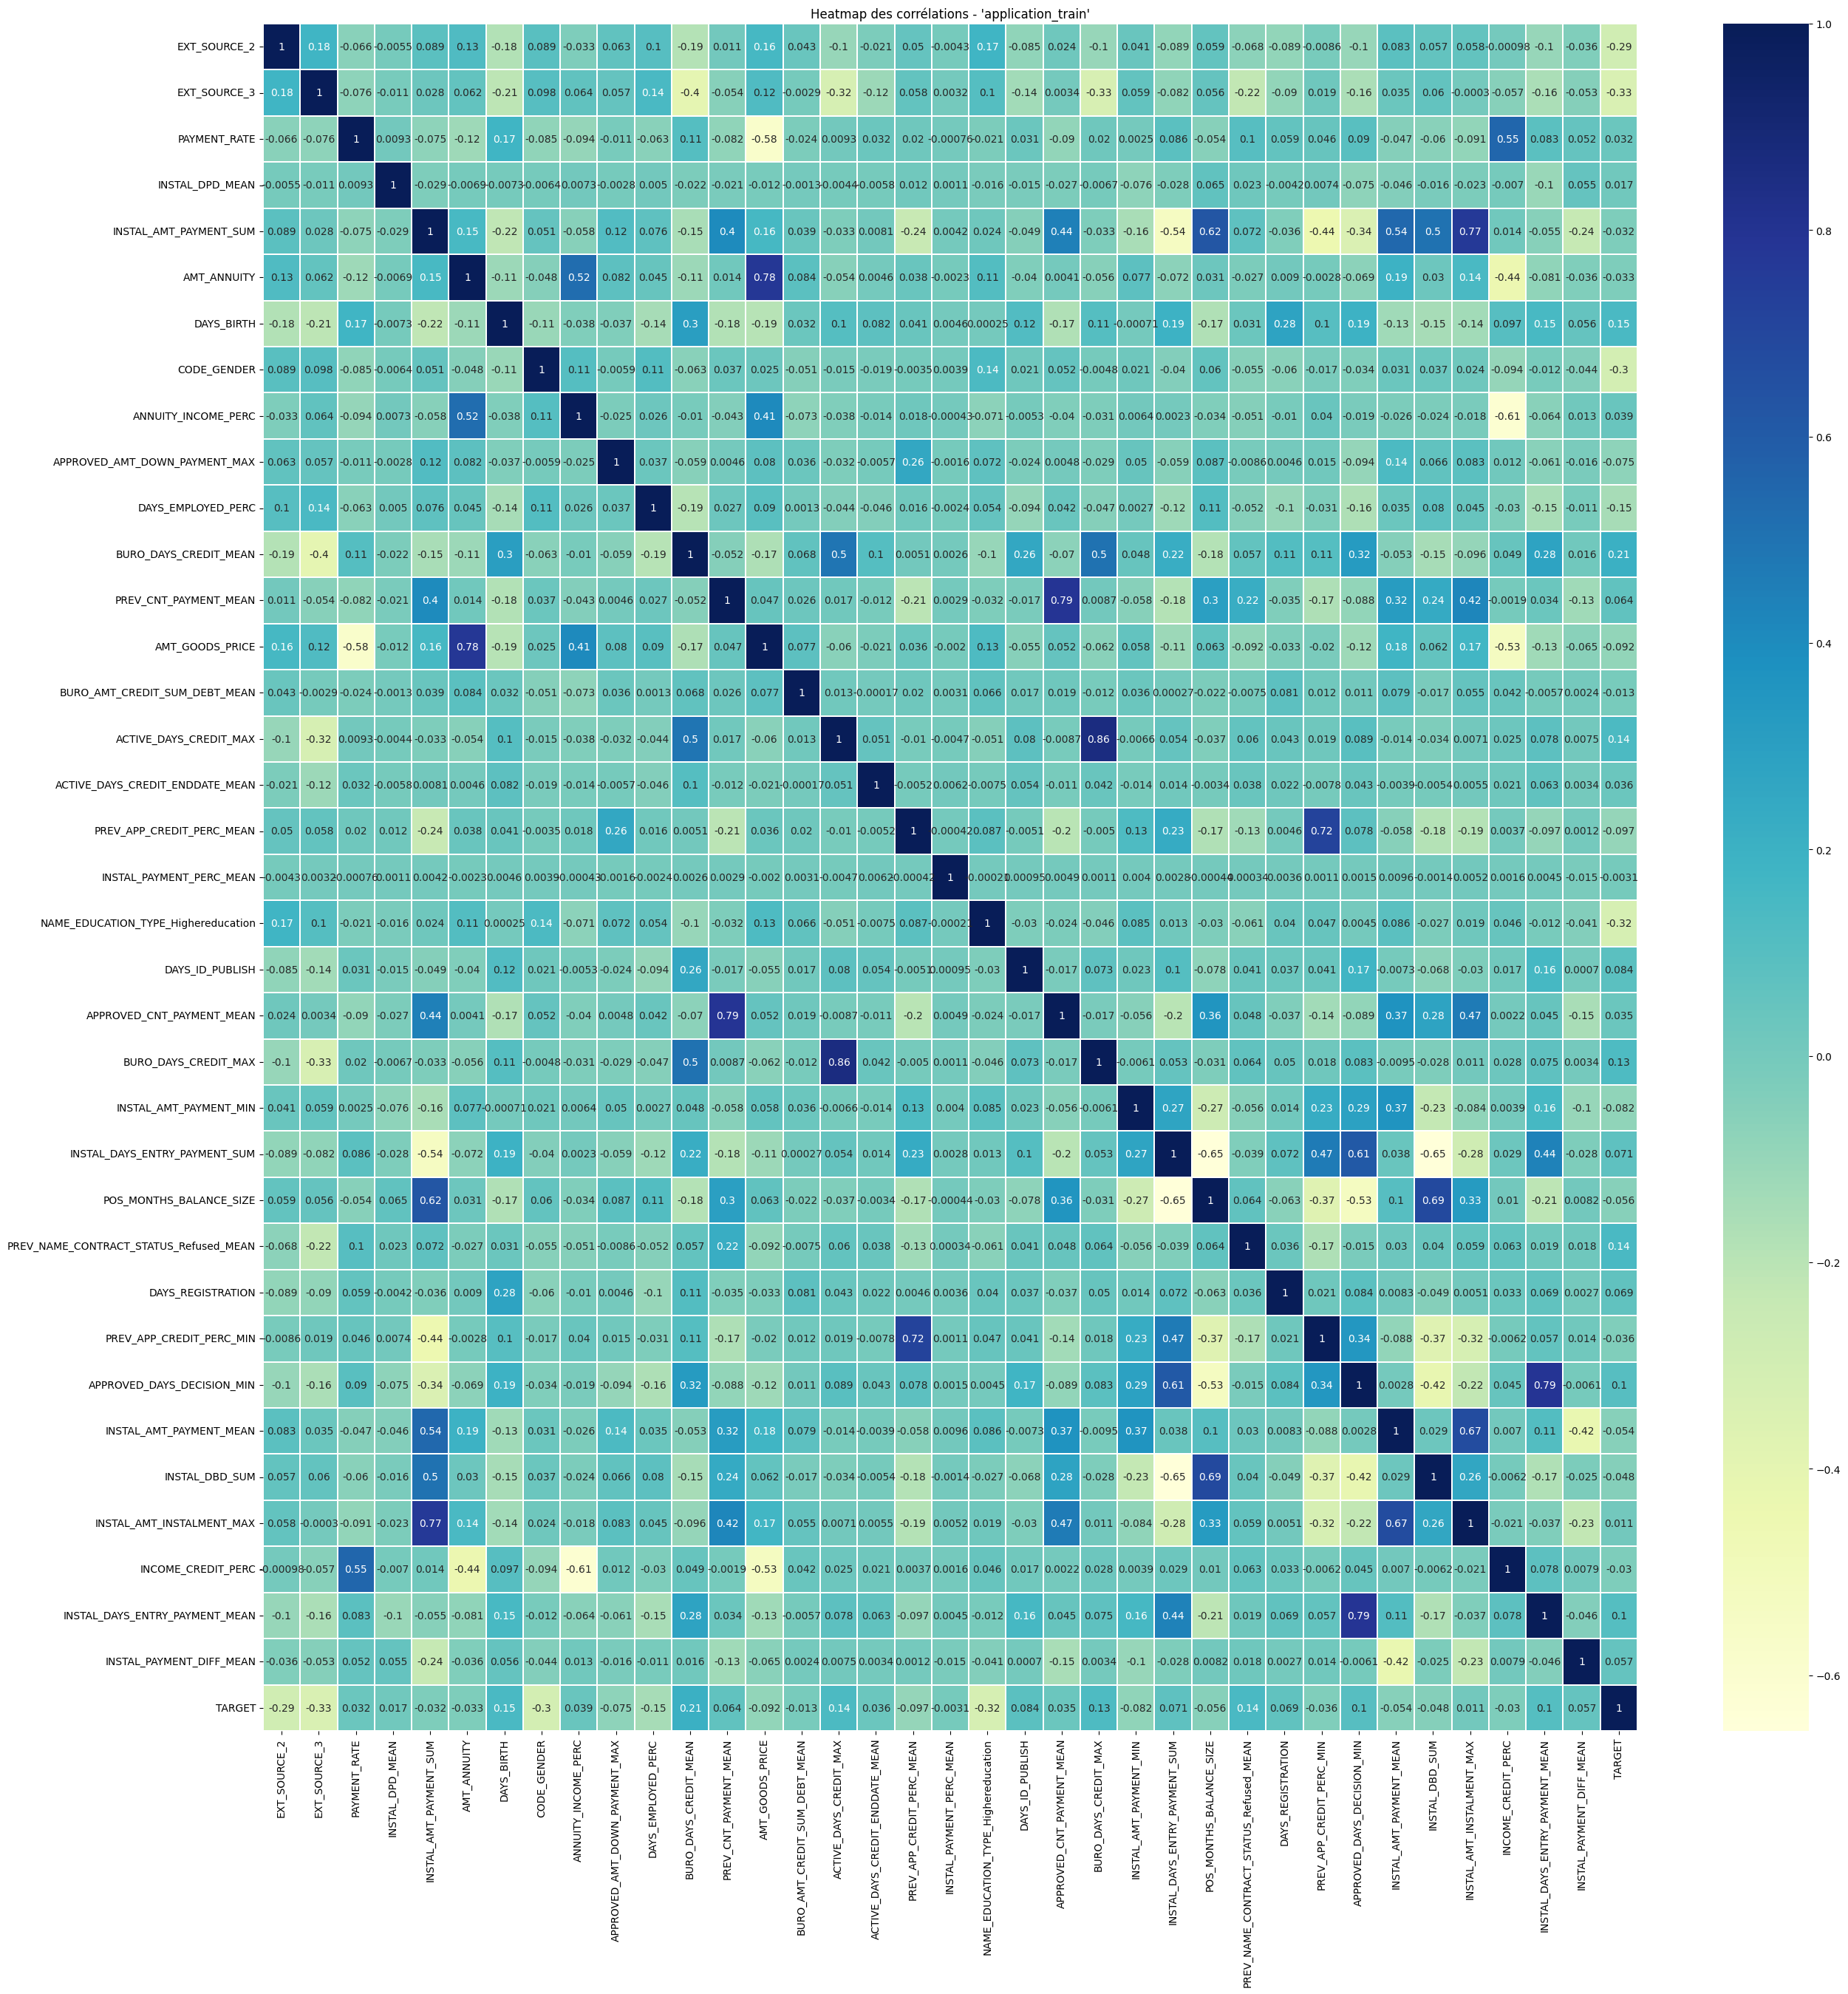

In [102]:
heatmap(train_df_cleaned_smote)

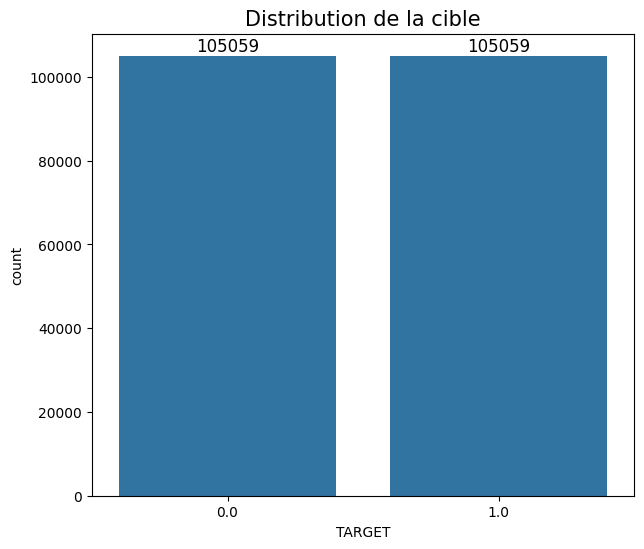

TARGET 0.0: 105059 occurrences (50.00%)
TARGET 1.0: 105059 occurrences (50.00%)


In [103]:
check_target(train_df_cleaned_smote)

## Export

In [104]:
train_df_cleaned_smote.shape

(210118, 37)

In [105]:
train_df_cleaned_smote.columns

Index(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'PAYMENT_RATE', 'INSTAL_DPD_MEAN',
       'INSTAL_AMT_PAYMENT_SUM', 'AMT_ANNUITY', 'DAYS_BIRTH', 'CODE_GENDER',
       'ANNUITY_INCOME_PERC', 'APPROVED_AMT_DOWN_PAYMENT_MAX',
       'DAYS_EMPLOYED_PERC', 'BURO_DAYS_CREDIT_MEAN', 'PREV_CNT_PAYMENT_MEAN',
       'AMT_GOODS_PRICE', 'BURO_AMT_CREDIT_SUM_DEBT_MEAN',
       'ACTIVE_DAYS_CREDIT_MAX', 'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN',
       'PREV_APP_CREDIT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_MEAN',
       'NAME_EDUCATION_TYPE_Highereducation', 'DAYS_ID_PUBLISH',
       'APPROVED_CNT_PAYMENT_MEAN', 'BURO_DAYS_CREDIT_MAX',
       'INSTAL_AMT_PAYMENT_MIN', 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
       'POS_MONTHS_BALANCE_SIZE', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
       'DAYS_REGISTRATION', 'PREV_APP_CREDIT_PERC_MIN',
       'APPROVED_DAYS_DECISION_MIN', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_DBD_SUM', 'INSTAL_AMT_INSTALMENT_MAX', 'INCOME_CREDIT_PERC',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEAN', 'INSTAL_PAYM

In [107]:
train_df_cleaned_smote.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,0.0


In [111]:
train_output_name = 'train_df_cleaned_smote'
test_output_name = 'test_df_cleaned'

#train_df_cleaned_smote.to_csv(csv_path_output + output_name + '.csv', encoding='ISO-8859-1')
train_df_cleaned_smote.to_parquet(csv_path_output + train_output_name + '.parquet.gzip', compression='gzip')
test_df_cleaned.to_parquet(csv_path_output + test_output_name + '.parquet.gzip', compression='gzip')

print('Export terminé')

Export terminé
